# Отбор признаков и сравнение метрик

В первой части рассматривается отбор признаков для самостоятельных ML-моделей. Replay-прогнозы в их входные данные не включаются. Разные наборы сравниваются на одинаковом временном разбиении: первые 80% кампаний используются для обучения, последние 20% для проверки.

Во второй части отдельно рассматривается калибровка replay, где replay используется как базовый прогноз, а ML обучается исправлять его ошибки. Чем меньше метрика, тем лучше результат.


## 1. Импорты и загрузка результатов


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

results = pd.read_csv(ROOT / "feature_selection_results.tsv", sep="\t")
selected_features = [
    line.strip()
    for line in (ROOT / "selected_features.txt").read_text(encoding="utf-8").splitlines()
    if line.strip()
]

display(results)
print(f"Выбрано признаков: {len(selected_features)}")


,feature_set,feature_count,metric
0,without_audience,63,15.25
1,top_40,40,15.32
2,top_5,5,15.33
3,top_30,30,15.33
4,top_25,25,15.65
5,without_publisher,69,15.80
6,top_50,50,16.03
7,top_80,80,16.15
8,top_20,20,16.18
9,top_15,15,16.24


Выбрано признаков: 63


## 2. Как проводился отбор

Перед отбором из таблицы исключаются три `shift_replay_*` столбца. Самостоятельный CatBoost обучается только на 97 обычных признаках.

Проверялись три типа наборов:

- `only_*` содержит только одну группу признаков;
- `without_*` содержит все признаки, кроме указанной группы;
- `top_*` содержит несколько самых важных признаков по CatBoost.

Группы признаков:

- `base` - параметры кампании;
- `audience` - характеристики аудитории;
- `publisher` - статистики площадок;
- `recent` - агрегаты истории за последние 31 день.

Для каждого набора CatBoost обучался заново. Метрика считалась на последних 20% кампаний по времени.


## 3. Основные результаты


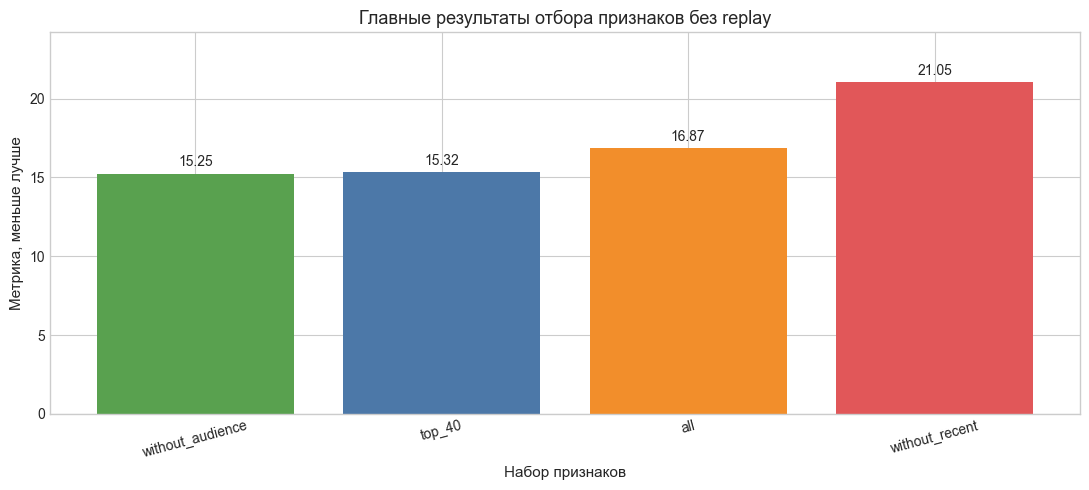

,feature_set,feature_count,metric
0,without_audience,63,15.25
1,top_40,40,15.32
2,all,97,16.87
3,without_recent,73,21.05


In [2]:
main_sets = ["without_audience", "top_40", "all", "without_recent"]
comparison = (
    results.set_index("feature_set")
    .loc[main_sets]
    .reset_index()
)

colors = ["#59A14F", "#4C78A8", "#F28E2B", "#E15759"]
bars = plt.bar(comparison["feature_set"], comparison["metric"], color=colors)
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Главные результаты отбора признаков без replay")
plt.xlabel("Набор признаков")
plt.ylabel("Метрика, меньше лучше")
plt.xticks(rotation=15)
plt.ylim(0, comparison["metric"].max() * 1.15)
plt.tight_layout()
plt.show()

display(comparison)


Лучший результат самостоятельного CatBoost получен без группы `audience_*`: 63 признака и метрика 15.25. Все 97 обычных признаков дают 16.87. Replay в этом эксперименте не используется.


## 4. Сравнение всех наборов


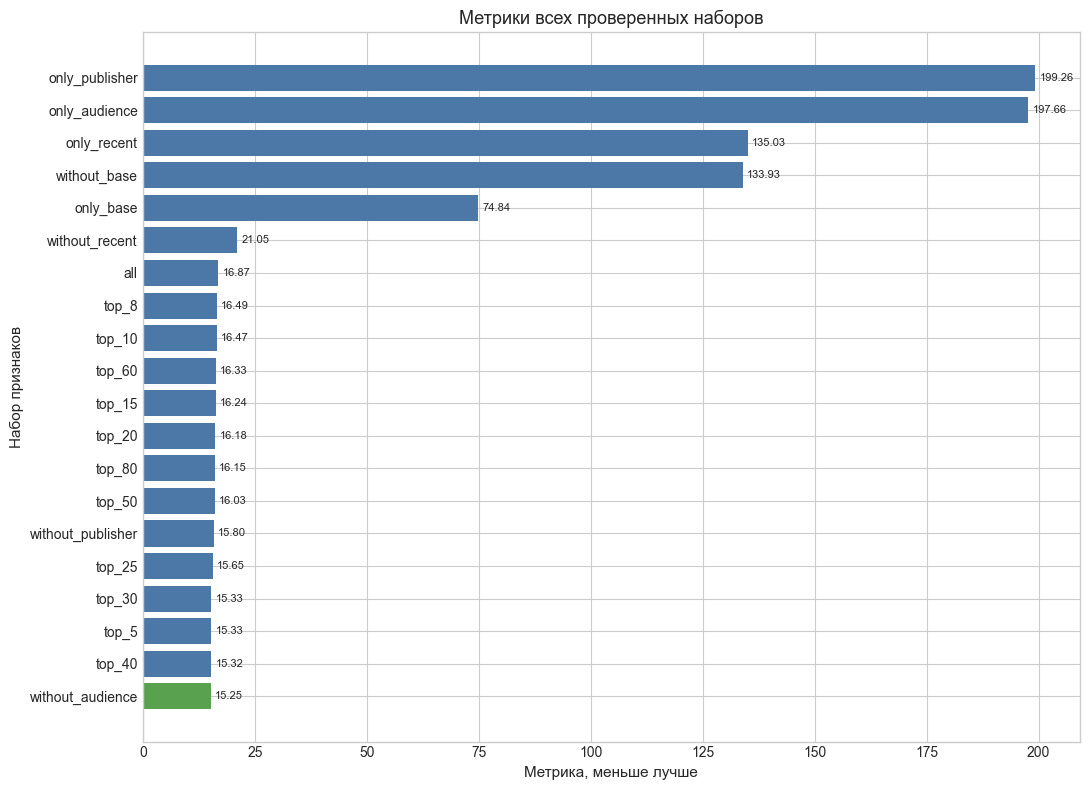

In [3]:
ordered = results.sort_values("metric", ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
colors = [
    "#59A14F" if name == results.iloc[0]["feature_set"] else "#4C78A8"
    for name in ordered["feature_set"]
]
bars = ax.barh(ordered["feature_set"], ordered["metric"], color=colors)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.set(
    title="Метрики всех проверенных наборов",
    xlabel="Метрика, меньше лучше",
    ylabel="Набор признаков",
)
plt.tight_layout()
plt.show()


## 5. Число признаков и качество


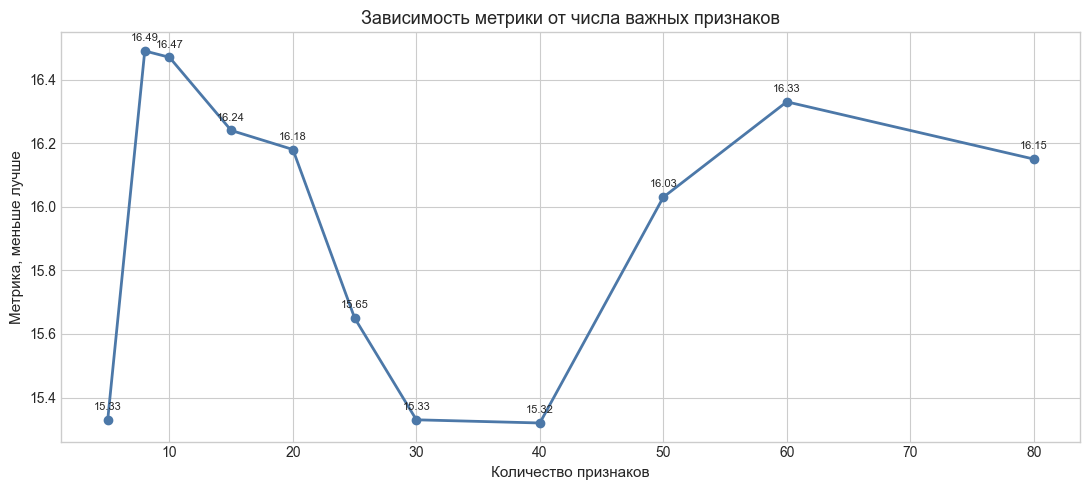

In [4]:
top_sets = results[results["feature_set"].str.startswith("top_")].sort_values("feature_count")

plt.plot(
    top_sets["feature_count"],
    top_sets["metric"],
    marker="o",
    linewidth=2,
    color="#4C78A8",
)
for row in top_sets.itertuples():
    plt.annotate(
        f"{row.metric:.2f}",
        (row.feature_count, row.metric),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )
plt.title("Зависимость метрики от числа важных признаков")
plt.xlabel("Количество признаков")
plt.ylabel("Метрика, меньше лучше")
plt.tight_layout()
plt.show()


## 6. Итоговый набор признаков


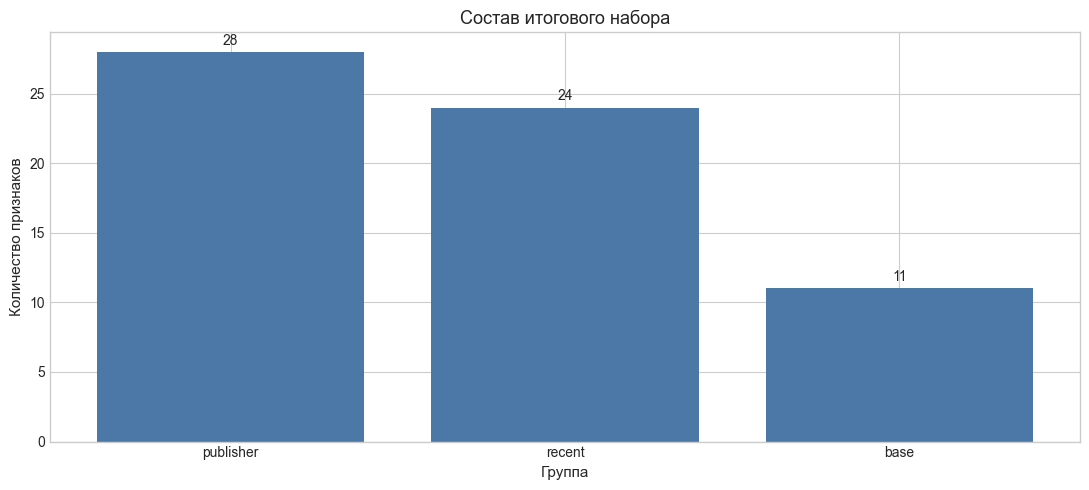

,feature,group
0,cpm,base
1,log_cpm,base
2,hour_start,base
3,hour_end,base
4,window_length,base
...,...,...
58,recent_31d_intersection_sessions_per_user,recent
59,recent_31d_intersection_cpm_mean,recent
60,recent_31d_intersection_win_rate,recent
61,cpm_to_pub_p90,base


In [5]:
def feature_group(feature):
    if feature.startswith("shift_replay_"):
        return "replay"
    if feature.startswith("audience_"):
        return "audience"
    if feature.startswith("publisher_"):
        return "publisher"
    if feature.startswith("recent_"):
        return "recent"
    return "base"


selected_table = pd.DataFrame({"feature": selected_features})
selected_table["group"] = selected_table["feature"].map(feature_group)
group_counts = selected_table["group"].value_counts()

bars = plt.bar(group_counts.index, group_counts.values, color="#4C78A8")
plt.bar_label(bars, padding=3)
plt.title("Состав итогового набора")
plt.xlabel("Группа")
plt.ylabel("Количество признаков")
plt.tight_layout()
plt.show()

display(selected_table)


### 6.1. Важность признаков CatBoost без replay

CatBoost обучается на первых 80% кампаний и на всех 97 обычных признаках. Три `shift_replay_*` столбца полностью исключаются. Важности трех моделей для `at_least_one`, `at_least_two` и `at_least_three` усредняются.


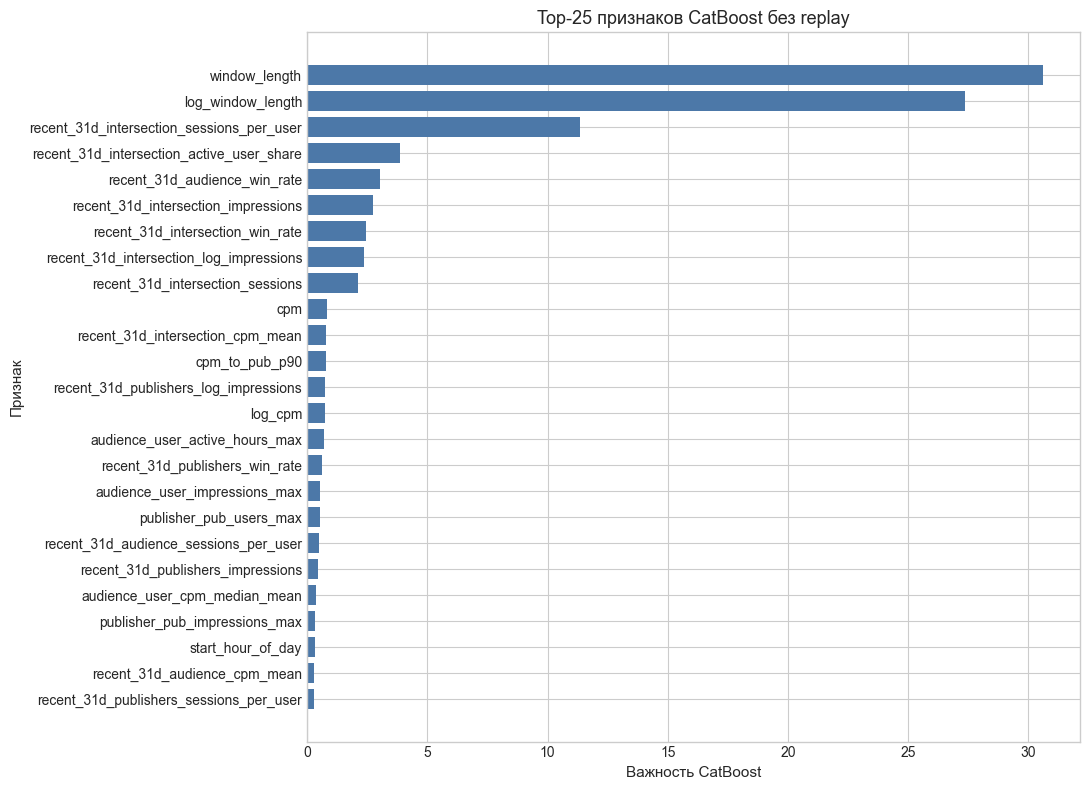

,feature,importance
0,window_length,30.612794
1,log_window_length,27.353564
2,recent_31d_intersection_sessions_per_user,11.352709
3,recent_31d_intersection_active_user_share,3.870119
4,recent_31d_audience_win_rate,3.040580
5,recent_31d_intersection_impressions,2.750739
6,recent_31d_intersection_win_rate,2.440881
7,recent_31d_intersection_log_impressions,2.353284
8,recent_31d_intersection_sessions,2.105360
9,cpm,0.818642


In [6]:
import sys
import numpy as np
from sklearn.multioutput import MultiOutputRegressor

sys.path.append(str(ROOT / "src"))
from ml_baseline import TARGET_COLUMNS, make_models, transform_target

all_features = pd.read_csv(ROOT / "features_validate.tsv", sep="\t")
standalone_features = all_features[
    [column for column in all_features if not column.startswith("shift_replay_")]
]
tasks = pd.read_csv(ROOT / "validate.tsv", sep="\t")
answers = pd.read_csv(ROOT / "validate_answers.tsv", sep="\t")[TARGET_COLUMNS]

ordered_indices = tasks.sort_values("hour_start").index.to_numpy()
valid_size = max(1, int(round(len(ordered_indices) * 0.2)))
train_indices = ordered_indices[:-valid_size]

standalone_model = MultiOutputRegressor(make_models()["catboost"])
standalone_model.fit(
    standalone_features.loc[train_indices],
    transform_target(answers.loc[train_indices]),
)
standalone_importance = np.mean(
    [estimator.get_feature_importance() for estimator in standalone_model.estimators_],
    axis=0,
)
standalone_importance_df = (
    pd.DataFrame({
        "feature": standalone_features.columns,
        "importance": standalone_importance,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_standalone = standalone_importance_df.head(25).sort_values("importance")
plt.figure(figsize=(11, 8))
plt.barh(top_standalone["feature"], top_standalone["importance"], color="#4C78A8")
plt.title("Top-25 признаков CatBoost без replay")
plt.xlabel("Важность CatBoost")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

display(standalone_importance_df.head(25))


## 7. Отбор признаков для калибровки replay

В этом эксперименте replay остается основным прогнозом, а ML предсказывает только поправку к нему. Поэтому три replay-признака сохраняются во всех наборах. Отбираются дополнительные признаки, которые помогают исправлять ошибки replay.


### 7.1. Важность дополнительных признаков для калибровки replay

Для ранжирования обучается консервативный CatBoost, который предсказывает ошибку replay. Сами три replay-прогноза не входят в рейтинг: они сохраняются во всех вариантах как основа. График показывает обычные признаки, наиболее полезные для расчета поправки.


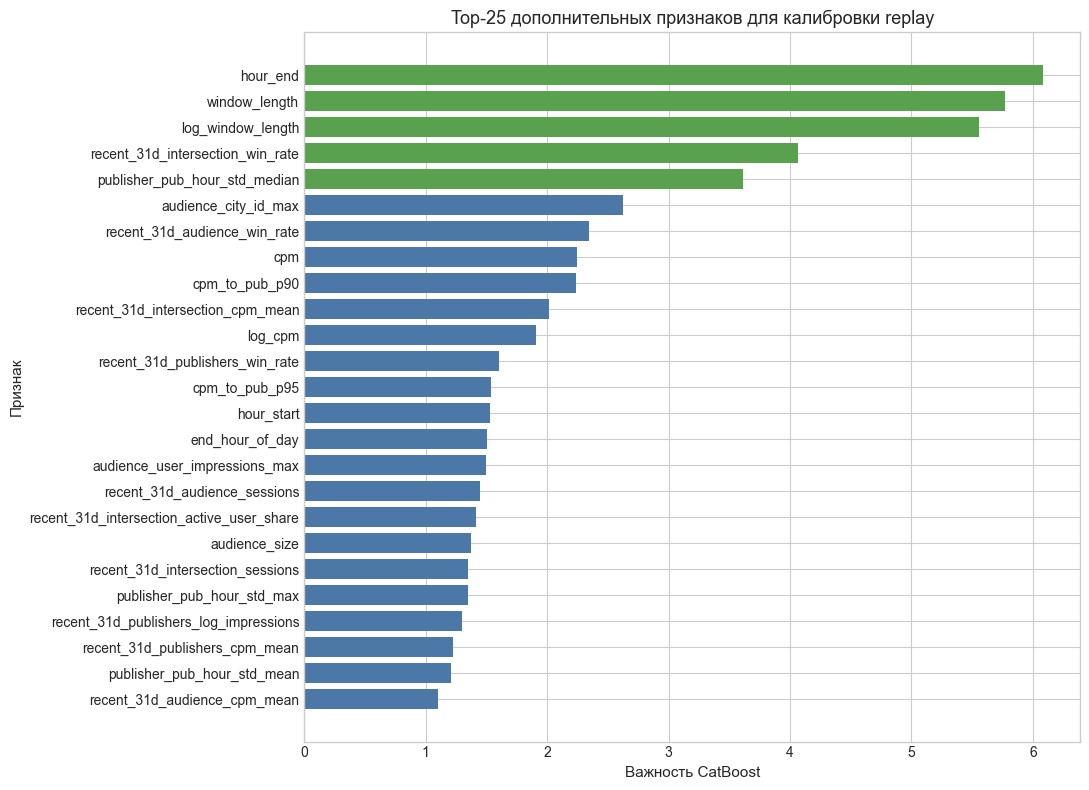

,feature,importance
0,hour_end,6.083712
1,window_length,5.773389
2,log_window_length,5.558039
3,recent_31d_intersection_win_rate,4.064621
4,publisher_pub_hour_std_median,3.616614
5,audience_city_id_max,2.627097
6,recent_31d_audience_win_rate,2.342106
7,cpm,2.243095
8,cpm_to_pub_p90,2.233417
9,recent_31d_intersection_cpm_mean,2.012649


In [7]:
from replay_calibration import get_base_predictions, make_calibration_models

calibration_features = [
    line.strip()
    for line in (ROOT / "selected_calibration_features.txt")
    .read_text(encoding="utf-8")
    .splitlines()
    if line.strip()
]
replay_columns = [column for column in all_features if column.startswith("shift_replay_")]
correction_columns = [column for column in all_features if column not in replay_columns]
base_log = transform_target(get_base_predictions(all_features))
answer_log = transform_target(answers)
residual_target = answer_log - base_log

calibration_ranker = MultiOutputRegressor(
    make_calibration_models()["catboost_conservative"]
)
calibration_ranker.fit(
    all_features.loc[train_indices, correction_columns],
    residual_target[train_indices],
)
calibration_importance = np.mean(
    [estimator.get_feature_importance() for estimator in calibration_ranker.estimators_],
    axis=0,
)
calibration_importance_df = (
    pd.DataFrame({
        "feature": correction_columns,
        "importance": calibration_importance,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_calibration = calibration_importance_df.head(25).sort_values("importance")
selected_extra = set(calibration_features) - set(replay_columns)
colors = [
    "#59A14F" if feature in selected_extra else "#4C78A8"
    for feature in top_calibration["feature"]
]
plt.figure(figsize=(11, 8))
plt.barh(top_calibration["feature"], top_calibration["importance"], color=colors)
plt.title("Top-25 дополнительных признаков для калибровки replay")
plt.xlabel("Важность CatBoost")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

display(calibration_importance_df.head(25))


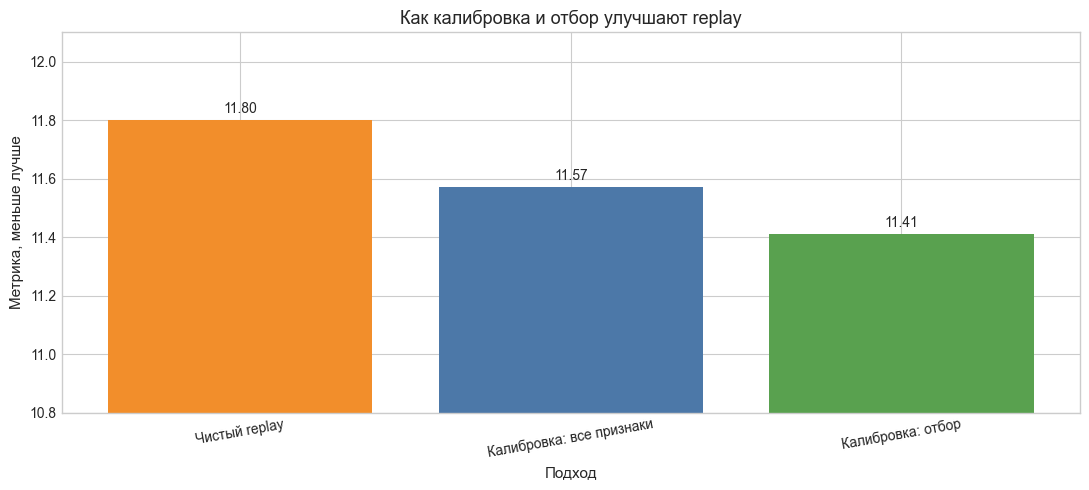

,variant,metric
0,Чистый replay,11.80
1,Калибровка: все признаки,11.57
2,Калибровка: отбор,11.41


In [8]:
calibration_results = pd.read_csv(
    ROOT / "calibration_feature_selection_results.tsv",
    sep="\t",
)
calibration_features = [
    line.strip()
    for line in (ROOT / "selected_calibration_features.txt")
    .read_text(encoding="utf-8")
    .splitlines()
    if line.strip()
]

main_calibration = pd.DataFrame({
    "variant": ["Чистый replay", "Калибровка: все признаки", "Калибровка: отбор"],
    "metric": [
        11.80,
        calibration_results.loc[
            calibration_results["feature_set"] == "all", "metric"
        ].iloc[0],
        calibration_results.iloc[0]["metric"],
    ],
})

colors = ["#F28E2B", "#4C78A8", "#59A14F"]
bars = plt.bar(main_calibration["variant"], main_calibration["metric"], color=colors)
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Как калибровка и отбор улучшают replay")
plt.xlabel("Подход")
plt.ylabel("Метрика, меньше лучше")
plt.ylim(10.8, 12.1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

display(main_calibration)


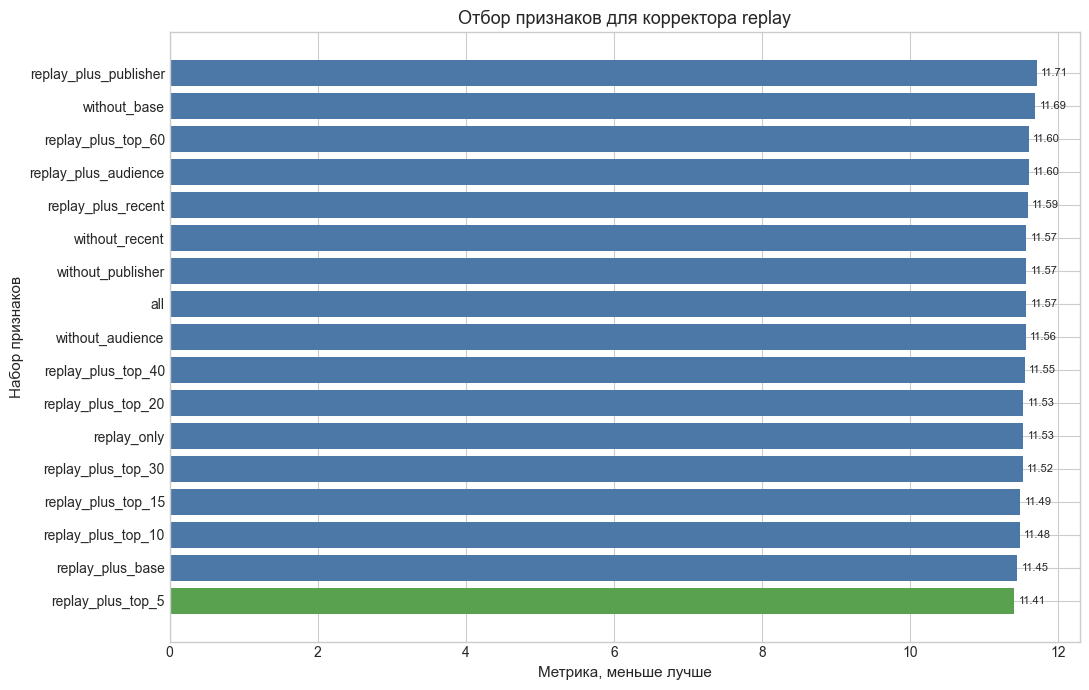

,feature_set,feature_count,model,shrink,metric
0,replay_plus_top_5,8,ridge_50,0.90,11.41
1,replay_plus_base,14,ridge_50,0.80,11.45
2,replay_plus_top_10,13,ridge_50,0.75,11.48
3,replay_plus_top_15,18,catboost_conservative,0.60,11.49
4,replay_plus_top_30,33,catboost_conservative,0.70,11.52
5,replay_only,3,ridge_50,0.95,11.53
6,replay_plus_top_20,23,ridge_50,0.60,11.53
7,replay_plus_top_40,43,elastic_net,0.60,11.55
8,without_audience,66,elastic_net,0.55,11.56
9,all,100,catboost_conservative,0.65,11.57


In [9]:
ordered_calibration = calibration_results.sort_values("metric", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
colors = [
    "#59A14F" if name == "replay_plus_top_5" else "#4C78A8"
    for name in ordered_calibration["feature_set"]
]
bars = ax.barh(
    ordered_calibration["feature_set"],
    ordered_calibration["metric"],
    color=colors,
)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.set(
    title="Отбор признаков для корректора replay",
    xlabel="Метрика, меньше лучше",
    ylabel="Набор признаков",
)
plt.tight_layout()
plt.show()

display(calibration_results)


Лучший набор `replay_plus_top_5` содержит три replay-прогноза и пять дополнительных признаков. Для него лучший результат показывает Ridge со `shrink = 0.90`: метрика 11.41. Использование всех 100 признаков дает 11.57, поэтому компактный набор меньше переобучается и лучше исправляет replay.


In [10]:
pd.DataFrame({"selected_calibration_feature": calibration_features})


,selected_calibration_feature
0,shift_replay_at_least_one
1,shift_replay_at_least_two
2,shift_replay_at_least_three
3,hour_end
4,window_length
5,log_window_length
6,recent_31d_intersection_win_rate
7,publisher_pub_hour_std_median


## 8. Сравнение моделей

Все модели обучаются на одинаковых 63 выбранных признаках без replay и проверяются на последних 20% кампаний по времени. Поэтому значения метрики можно сравнивать напрямую.


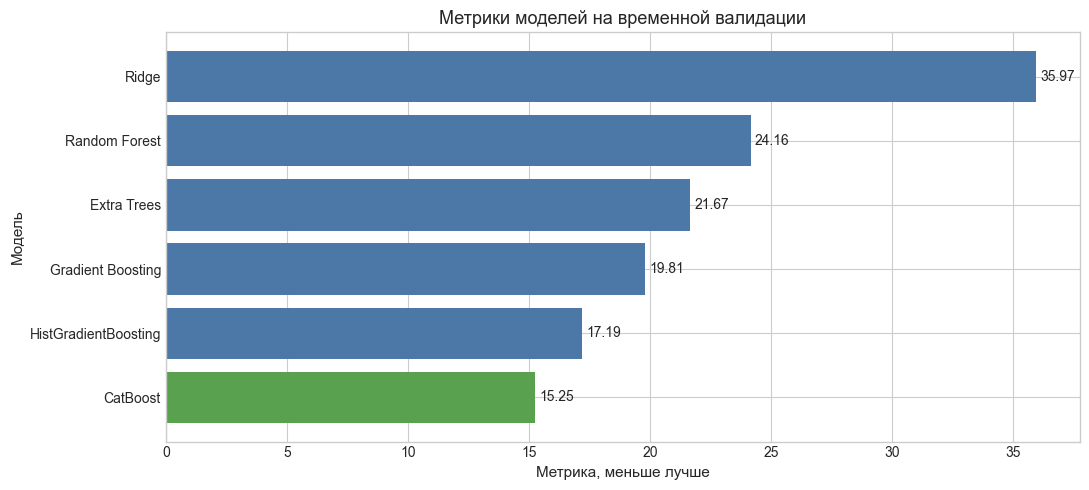

,model,metric
0,catboost,15.25
1,hist_gradient_boosting,17.19
2,gradient_boosting,19.81
3,extra_trees,21.67
4,random_forest,24.16
5,ridge,35.97


In [11]:
model_metrics = pd.read_csv(ROOT / "model_metrics.tsv", sep="\t")
model_metrics = model_metrics.sort_values("metric", ascending=True)

labels = {
    "catboost": "CatBoost",
    "extra_trees": "Extra Trees",
    "gradient_boosting": "Gradient Boosting",
    "random_forest": "Random Forest",
    "hist_gradient_boosting": "HistGradientBoosting",
    "ridge": "Ridge",
}
plot_data = model_metrics.copy()
plot_data["model_name"] = plot_data["model"].map(labels)

colors = [
    "#59A14F" if model == "catboost" else "#4C78A8"
    for model in plot_data["model"]
]
bars = plt.barh(plot_data["model_name"], plot_data["metric"], color=colors)
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Метрики моделей на временной валидации")
plt.xlabel("Метрика, меньше лучше")
plt.ylabel("Модель")
plt.tight_layout()
plt.show()

display(model_metrics[["model", "metric"]].reset_index(drop=True))


Лучший результат среди самостоятельных ML-моделей показывает CatBoost с метрикой 15.25. HistGradientBoosting дает 17.19, Gradient Boosting 19.81. Replay в признаки этих моделей не входит.


## 9. Вывод

Для самостоятельного CatBoost выбран набор из 63 обычных признаков без `audience_*` и без replay. Метрика на временной валидации улучшилась с **16.87** до **15.25**.

Replay рассматривается отдельно. Лучший итоговый подход использует replay как базовый прогноз и Ridge-корректор. После отдельного отбора корректору оставлены 8 признаков, а метрика улучшилась с **11.80** до **11.41**.

Таким образом, сравниваются два разных подхода: чистый табличный ML без replay и отдельная ML-калибровка replay.
